### Importación de datos



In [277]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda1 = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda1.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación



In [278]:
for i, tienda in enumerate([tienda1, tienda2, tienda3, tienda4], start=1):
    print(f"\n--- Tienda {i} ---")
    print(tienda.info())
    print(tienda.head())


--- Tienda 1 ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2359 entries, 0 to 2358
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Producto                2359 non-null   object 
 1   Categoría del Producto  2359 non-null   object 
 2   Precio                  2359 non-null   float64
 3   Costo de envío          2359 non-null   float64
 4   Fecha de Compra         2359 non-null   object 
 5   Vendedor                2359 non-null   object 
 6   Lugar de Compra         2359 non-null   object 
 7   Calificación            2359 non-null   int64  
 8   Método de pago          2359 non-null   object 
 9   Cantidad de cuotas      2359 non-null   int64  
 10  lat                     2359 non-null   float64
 11  lon                     2359 non-null   float64
dtypes: float64(4), int64(2), object(6)
memory usage: 221.3+ KB
None
            Producto Categoría del Producto    Precio  Costo de 

In [279]:
ingreso_tienda1 = tienda1["Precio"].sum()
ingreso_tienda2 = tienda2["Precio"].sum()
ingreso_tienda3 = tienda3["Precio"].sum()
ingreso_tienda4 = tienda4["Precio"].sum()

print("Ingreso total de la tienda 1:", ingreso_tienda)
print("Ingreso total de la tienda 2:", ingreso_tienda2)
print("Ingreso total de la tienda 3:", ingreso_tienda3)
print("Ingreso total de la tienda 4:", ingreso_tienda4)

Ingreso total de la tienda 1: 1038375700.0
Ingreso total de la tienda 2: 1116343500.0
Ingreso total de la tienda 3: 1098019600.0
Ingreso total de la tienda 4: 1038375700.0


In [280]:
df_ingresos = pd.DataFrame({
    "Tienda": ["Tienda 1", "Tienda 2", "Tienda 3", "Tienda 4"],
    "Ingresos": [ingreso_tienda1, ingreso_tienda2, ingreso_tienda3, ingreso_tienda4]
})

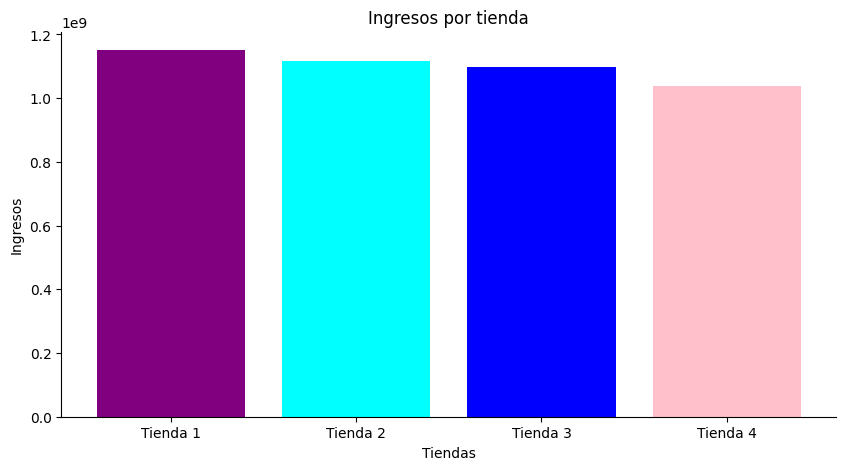

In [281]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(df_ingresos["Tienda"], df_ingresos["Ingresos"], color=['purple', 'cyan', 'blue', 'pink'])

plt.title("Ingresos por tienda")
plt.xlabel("Tiendas")
plt.ylabel("Ingresos")
plt.xticks(rotation=0)
plt.gca().spines[['top','right']].set_visible(False)

plt.show()

# 2. Ventas por categoría

In [282]:
def ventas_por_categoria(df):
    return df.groupby('Categoría del Producto')['Precio'].sum().sort_values(ascending=False)

ventas_categorias = {
    'Tienda 1': ventas_por_categoria(tienda1),
    'Tienda 2': ventas_por_categoria(tienda2),
    'Tienda 3': ventas_por_categoria(tienda3),
    'Tienda 4': ventas_por_categoria(tienda4)
}

for tienda, ventas in ventas_categorias.items():
    print(f"\n--- Ventas por Categoría en {tienda} ---")
    print(ventas.to_string())



--- Ventas por Categoría en Tienda 1 ---
Categoría del Producto
Electrónicos               429493500.0
Electrodomésticos          363685200.0
Muebles                    187633700.0
Instrumentos musicales      91299000.0
Deportes y diversión        39290000.0
Juguetes                    17995700.0
Artículos para el hogar     12698400.0
Libros                       8784900.0

--- Ventas por Categoría en Tienda 2 ---
Categoría del Producto
Electrónicos               410831100.0
Electrodomésticos          348567800.0
Muebles                    176426300.0
Instrumentos musicales     104990300.0
Deportes y diversión        34744500.0
Juguetes                    15945400.0
Artículos para el hogar     14746900.0
Libros                      10091200.0

--- Ventas por Categoría en Tienda 3 ---
Categoría del Producto
Electrónicos               410775800.0
Electrodomésticos          329237900.0
Muebles                    201072100.0
Instrumentos musicales      77380900.0
Deportes y diversión     

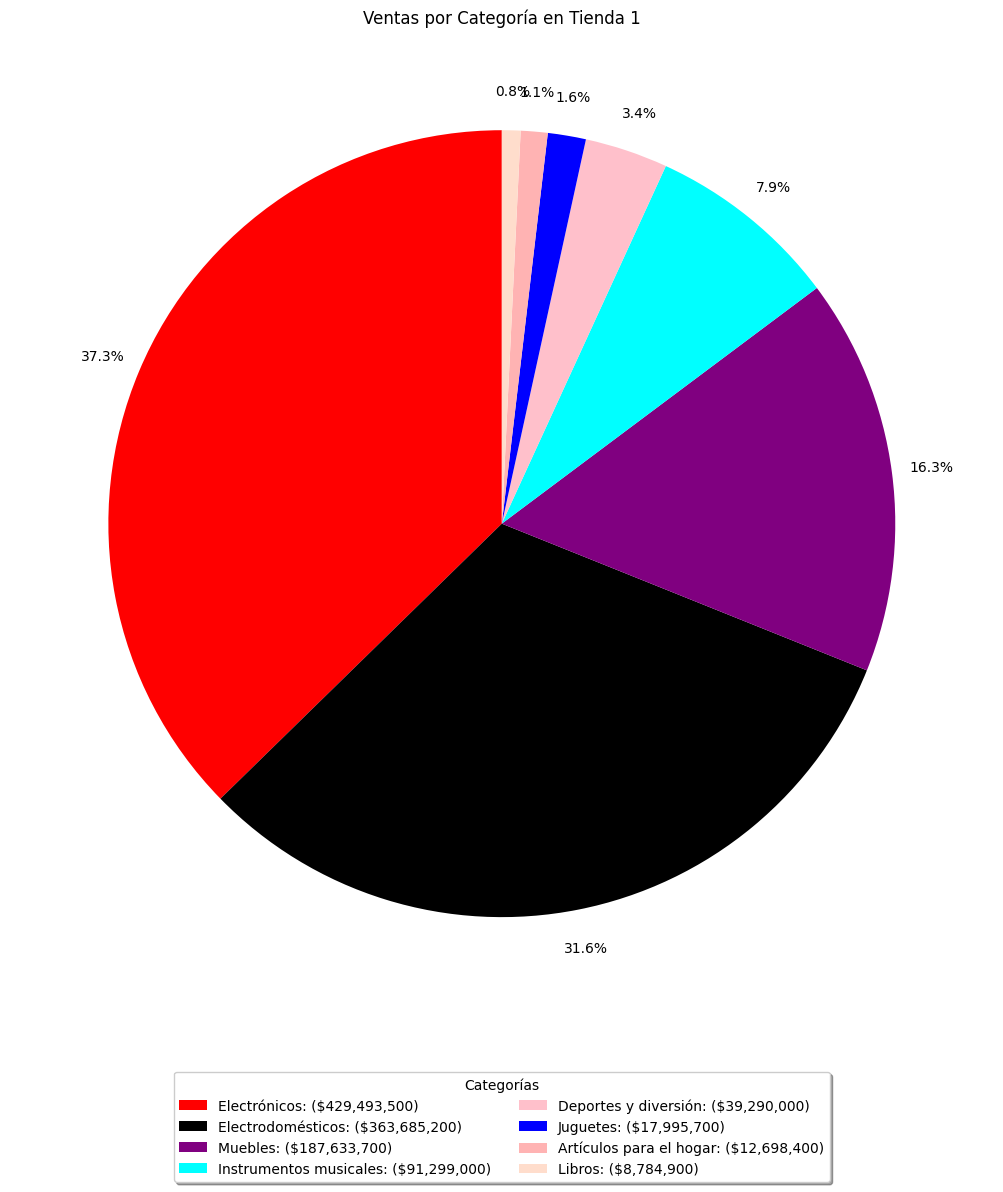

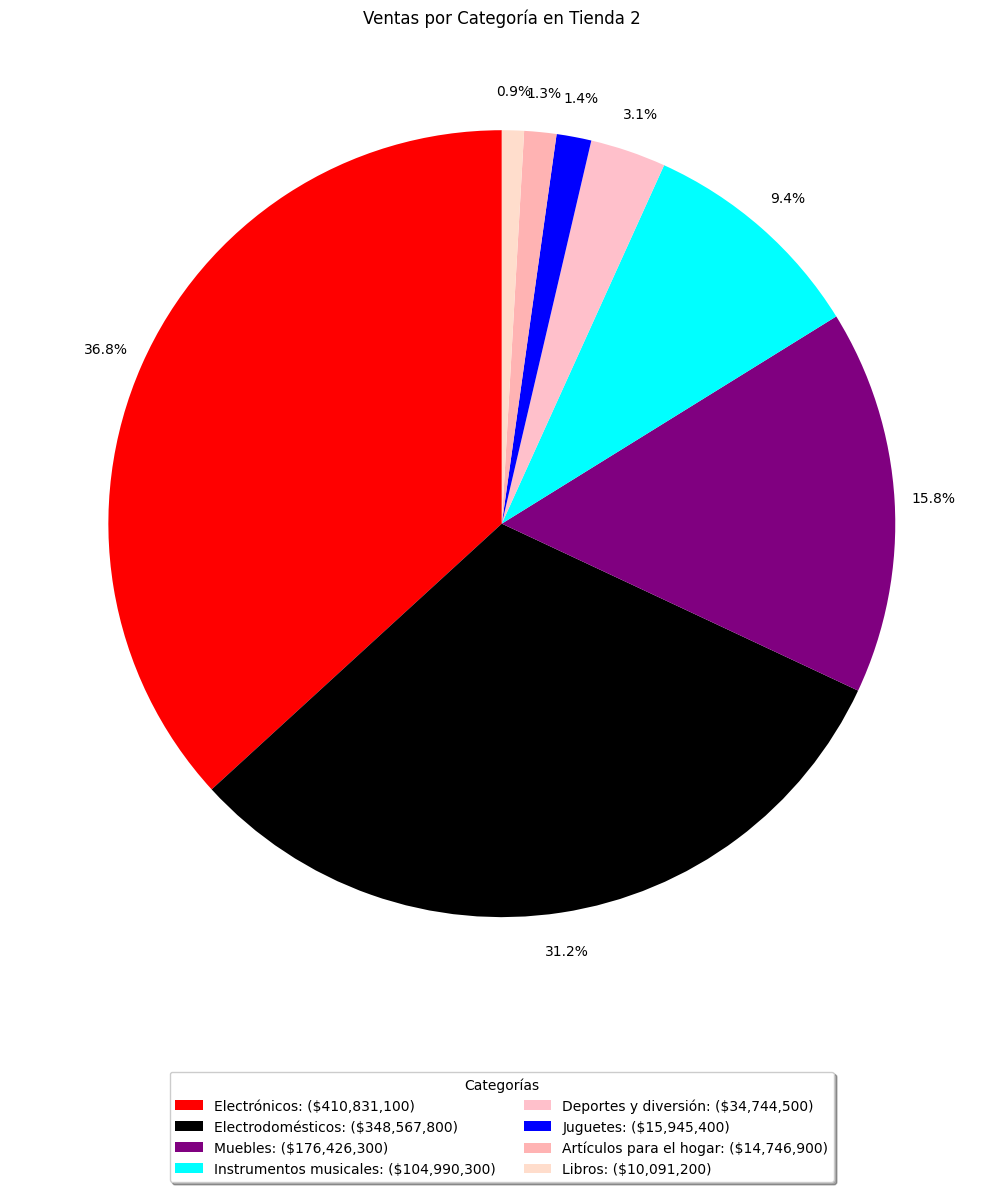

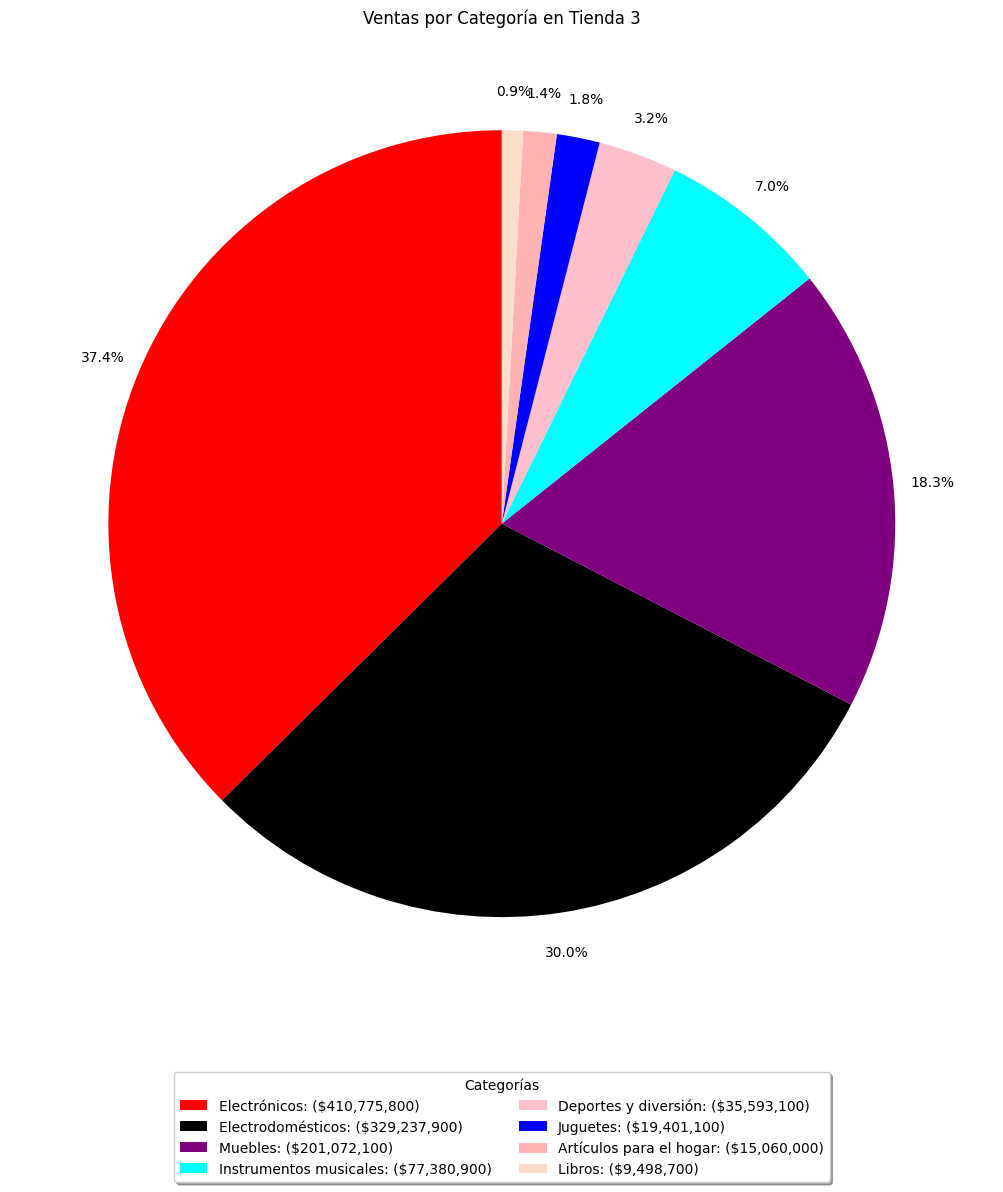

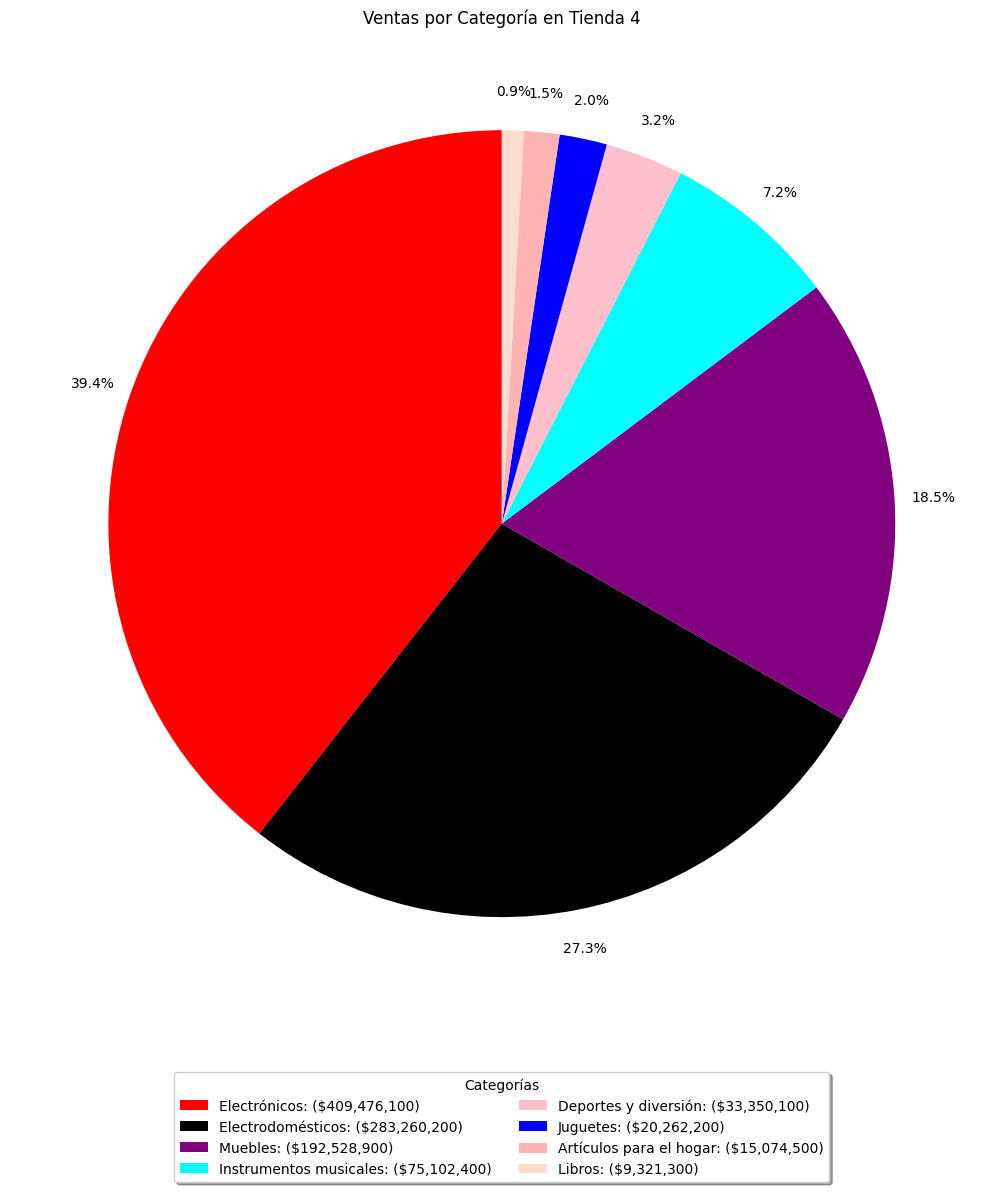

In [283]:
import matplotlib.pyplot as plt
import numpy as np

#Definimos colores para la gráfica
colores_grafica = ['red', 'black', 'purple', 'cyan', 'pink', 'blue', '#FFB3B3', '#FFDDCC']

#Ploteamos las ventas por categoría de cada tienda
for tienda, ventas in ventas_categorias.items():
    plt.figure(figsize=(12, 12))
    wedges, texts = plt.pie(ventas, startangle=90, colors=colores_grafica)
    plt.title(f'Ventas por Categoría en {tienda}')
#Escondemos la etiqueta del eje Y
    plt.ylabel('')

#Añdimos los porcentajes de ventas alrededor de la gráfica
    total = ventas.sum()
    for i, wedge in enumerate(wedges):
        angle = (wedge.theta2 + wedge.theta1) / 2.
        x = 1.1 * np.cos(np.deg2rad(angle))
        y = 1.1 * np.sin(np.deg2rad(angle))
        plt.text(x, y, f'{ventas.iloc[i]/total:.1%}', ha='center', va='center')

#Creamos y añadimos la anotación de categorías y la sumatoria de ventas
    legend_labels = [f'{label}: (${ventas.loc[label]:,.0f})' for label in ventas.index]
    plt.legend(wedges, legend_labels, title="Categorías", loc="upper center", bbox_to_anchor=(0.5, -0.05),
               fancybox=True, shadow=True, ncol=2)

    plt.tight_layout()
    plt.show()

# 3. Calificación promedio de la tienda


In [284]:
calificacion_tienda1 = tienda1["Calificación"].mean()
calificacion_tienda2 = tienda2["Calificación"].mean()
calificacion_tienda3 = tienda3["Calificación"].mean()
calificacion_tienda4 = tienda4["Calificación"].mean()

print("Calificación promedio tienda 1:", calificacion_tienda1)
print("Calificación promedio tienda 2:", calificacion_tienda2)
print("Calificación promedio tienda 3:", calificacion_tienda3)
print("Calificación promedio tienda 4:", calificacion_tienda4)

Calificación promedio tienda 1: 3.976685036032217
Calificación promedio tienda 2: 4.037303942348453
Calificación promedio tienda 3: 4.048325561678677
Calificación promedio tienda 4: 3.9957591178965224


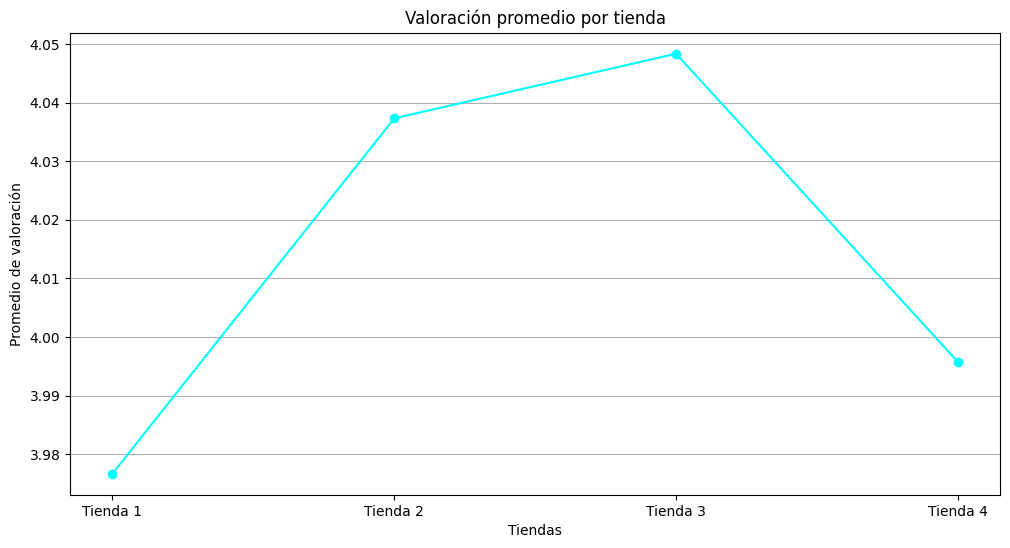

In [285]:
promedios = [
    tienda1["Calificación"].mean(),
    tienda2["Calificación"].mean(),
    tienda3["Calificación"].mean(),
    tienda4["Calificación"].mean()
]

plt.figure(figsize=(12,6))
plt.plot(["Tienda 1", "Tienda 2", "Tienda 3", "Tienda 4"], promedios, marker='o', color='cyan')
plt.title("Valoración promedio por tienda")
plt.ylabel("Promedio de valoración")
plt.xlabel("Tiendas")
plt.grid(axis='y')
plt.show()

# 4. Productos más y menos vendidos

In [286]:
import pandas as pd

def productos_mas_vendidos(df):
    return df['Producto'].value_counts().head(1).reset_index(name='Cantidad Vendida').rename(columns={'index': 'Producto'})

def productos_menos_vendidos(df):
    return df['Producto'].value_counts().tail(1).reset_index(name='Cantidad Vendida').rename(columns={'index': 'Producto'})

tiendas = {
    'Tienda 1': tienda1,
    'Tienda 2': tienda2,
    'Tienda 3': tienda3,
    'Tienda 4': tienda4
}


mas_vendidos_tienda1_df = productos_mas_vendidos(tienda1)
menos_vendidos_tienda1_df = productos_menos_vendidos(tienda1)
mas_vendidos_tienda2_df = productos_mas_vendidos(tienda2)
menos_vendidos_tienda2_df = productos_menos_vendidos(tienda2)
mas_vendidos_tienda3_df = productos_mas_vendidos(tienda3)
menos_vendidos_tienda3_df = productos_menos_vendidos(tienda3)
mas_vendidos_tienda4_df = productos_mas_vendidos(tienda4)
menos_vendidos_tienda4_df = productos_menos_vendidos(tienda4)



for nombre, df in tiendas.items():
    mas_vendidos_df = productos_mas_vendidos(df)
    menos_vendidos_df = productos_menos_vendidos(df)
    print(f"Productos más vendidos en {nombre}")
    print(mas_vendidos_df)
    print(f"Productos menos vendidos en {nombre}")
    print(menos_vendidos_df)

Productos más vendidos en Tienda 1
     Producto  Cantidad Vendida
0  Microondas                60
Productos menos vendidos en Tienda 1
       Producto  Cantidad Vendida
0  Celular ABXY                33
Productos más vendidos en Tienda 2
                    Producto  Cantidad Vendida
0  Iniciando en programación                65
Productos menos vendidos en Tienda 2
        Producto  Cantidad Vendida
0  Juego de mesa                32
Productos más vendidos en Tienda 3
        Producto  Cantidad Vendida
0  Kit de bancas                57
Productos menos vendidos en Tienda 3
                  Producto  Cantidad Vendida
0  Bloques de construcción                35
Productos más vendidos en Tienda 4
   Producto  Cantidad Vendida
0  Cama box                62
Productos menos vendidos en Tienda 4
             Producto  Cantidad Vendida
0  Guitarra eléctrica                33


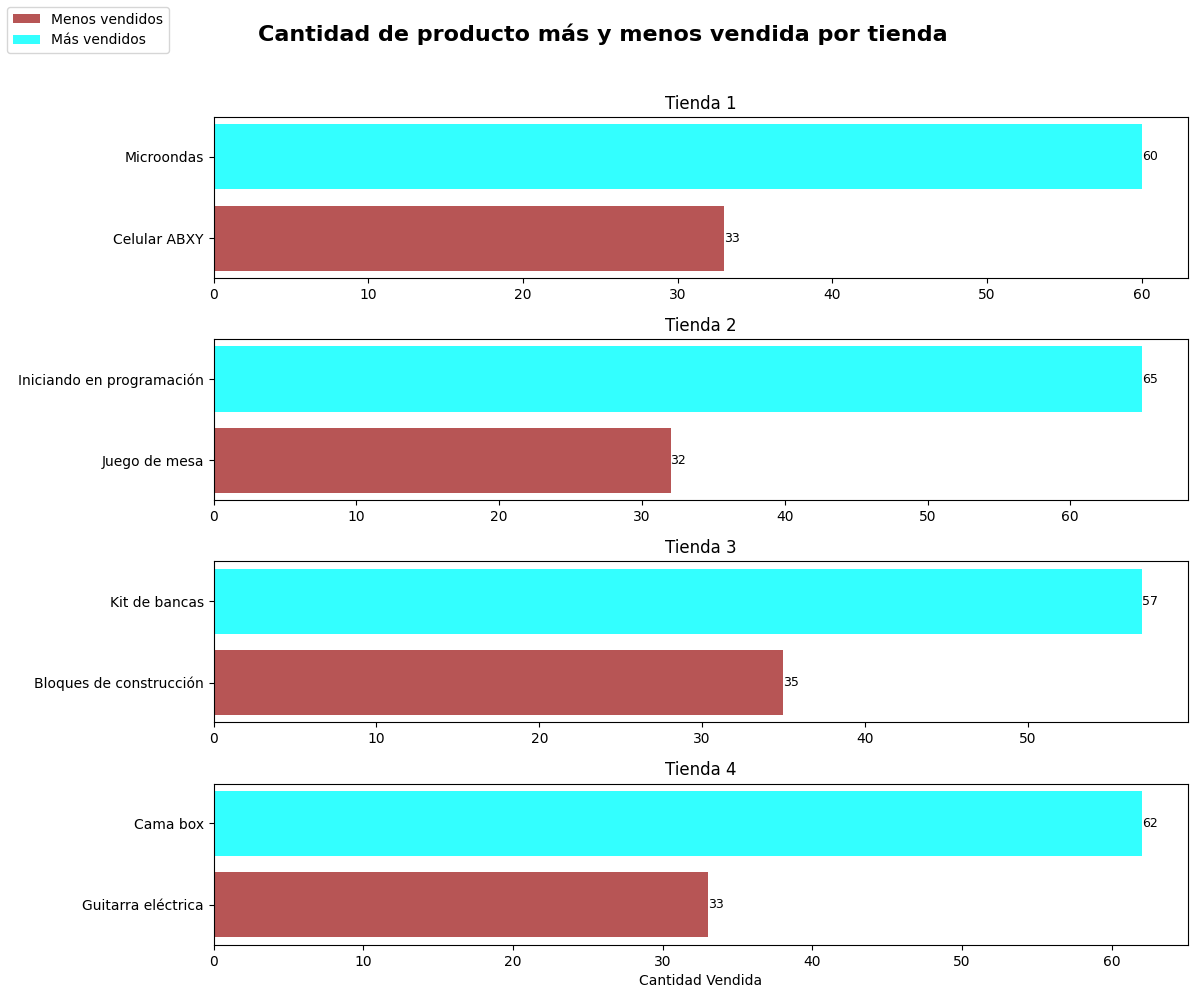

In [287]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

fig3, productos= plt.subplots(4,1, figsize=(12,10))
fig3.suptitle('Cantidad de producto más y menos vendida por tienda', fontsize = 16, fontweight='bold')

productos[0].barh(menos_vendidos_tienda1_df['Producto'], menos_vendidos_tienda1_df['Cantidad Vendida'], color='brown', alpha=0.8)
productos[0].barh(mas_vendidos_tienda1_df['Producto'], mas_vendidos_tienda1_df['Cantidad Vendida'], color='cyan', alpha=0.8)
productos[0].set_title('Tienda 1')

productos[1].barh(menos_vendidos_tienda2_df['Producto'], menos_vendidos_tienda2_df['Cantidad Vendida'], color='brown', alpha=0.8)
productos[1].barh(mas_vendidos_tienda2_df['Producto'], mas_vendidos_tienda2_df['Cantidad Vendida'], color='cyan', alpha=0.8)
productos[1].set_title('Tienda 2')

productos[2].barh(menos_vendidos_tienda3_df['Producto'], menos_vendidos_tienda3_df['Cantidad Vendida'], color='brown', alpha=0.8)
productos[2].barh(mas_vendidos_tienda3_df['Producto'], mas_vendidos_tienda3_df['Cantidad Vendida'], color='cyan', alpha=0.8)
productos[2].set_title('Tienda 3')

productos[3].barh(menos_vendidos_tienda4_df['Producto'], menos_vendidos_tienda4_df['Cantidad Vendida'], color='brown', alpha=0.8)
productos[3].barh(mas_vendidos_tienda4_df['Producto'], mas_vendidos_tienda4_df['Cantidad Vendida'], color='cyan', alpha=0.8)
productos[3].set_title('Tienda 4')
productos[3].set_xlabel('Cantidad Vendida')

for ax in productos:
  for bars in ax.containers:
    ax.bar_label(bars,fmt='%.0f',label_type='edge',fontsize=9)


fig3.legend(['Menos vendidos', 'Más vendidos'], loc='upper left')
plt.tight_layout(rect=[0,0,1,0.96]) # Para ajustar la imagen y que no se superpongan elementos
plt.show() # Added to display the plot

# 5. Envío promedio por tienda

In [288]:
envio_tienda1 = tienda1["Costo de envío"].mean()
envio_tienda2 = tienda2["Costo de envío"].mean()
envio_tienda3 = tienda3["Costo de envío"].mean()
envio_tienda4 = tienda4["Costo de envío"].mean()

print("Costo de envío promedio en Tienda 1:", envio_tienda1)
print("Costo de envío promedio en Tienda 2:", envio_tienda2)
print("Costo de envío promedio en Tienda 3:", envio_tienda3)
print("Costo de envío promedio en Tienda 4:", envio_tienda4)

Costo de envío promedio en Tienda 1: 26018.60958033065
Costo de envío promedio en Tienda 2: 25216.235693090293
Costo de envío promedio en Tienda 3: 24805.680373039424
Costo de envío promedio en Tienda 4: 23459.457167090754


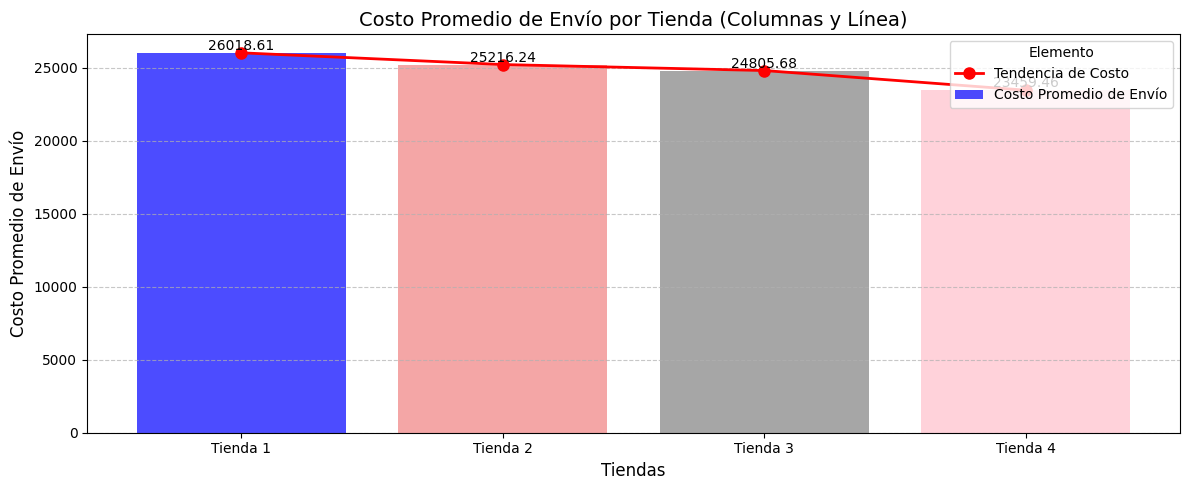

In [289]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


df_costos = pd.DataFrame({
    'Tienda': ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4'],
    'Costo Promedio de Envío': [envio_tienda1, envio_tienda2, envio_tienda3, envio_tienda4]
})

plt.figure(figsize=(12, 5))

stores = df_costos['Tienda']
costs = df_costos['Costo Promedio de Envío']
x_positions = np.arange(len(stores))
colors = ['blue', 'lightcoral', 'gray', 'pink']


plt.bar(x_positions, costs, color=colors, alpha=0.7, label='Costo Promedio de Envío')


plt.plot(x_positions, costs, color='red', linestyle='-', marker='o', markersize=8, linewidth=2, label='Tendencia de Costo')


for i, cost in enumerate(costs):
    plt.text(x_positions[i], cost, f'{cost:.2f}', ha='center', va='bottom', fontsize=10, color='black')

plt.xticks(x_positions, stores)
plt.xlabel('Tiendas', fontsize=12)
plt.ylabel('Costo Promedio de Envío', fontsize=12)
plt.title('Costo Promedio de Envío por Tienda (Columnas y Línea)', fontsize=14)
plt.legend(title='Elemento', loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(bottom=0)
plt.tight_layout()
plt.show()

## 6. Informe final

Introducción

El objetivo de este estudio es analizar el desempeño de las cuatro tiendas pertenecientes al Sr. Juan con el fin de identificar cuál presenta el menor nivel de rentabilidad o eficiencia. A partir de este análisis, se busca ofrecer una recomendación fundamentada sobre qué sucursal sería conveniente vender. Para ello, se consideran factores como los ingresos totales generados, la aceptación de las distintas categorías de productos, el nivel de satisfacción de los clientes y la eficiencia en los costos logísticos.

Análisis

Según el análisis de ingresos y la representación gráfica mediante barras, se observa una diferencia evidente en la capacidad de generación de ingresos entre las tiendas:

Tienda 1: Registra el mayor ingreso, alcanzando los 1.150.880.400.

Tienda 2: Obtiene un total de 1.116.343.500 en ingresos.

Tienda 3: Presenta una facturación de 1.098.019.600.

Tienda 4: Es la sucursal con el desempeño económico más bajo, con 1.038.375.700.

El estudio de las ventas por categoría permite identificar en qué mercados cada tienda tiene mayor o menor rendimiento:

Los productos electrónicos representan la principal fuente de ingresos en todas las tiendas. Sin embargo, la Tienda 4 muestra el valor más bajo en la categoría de Electrodomésticos (283.260.200), en comparación con los 363.685.200 generados por la Tienda 1.

La categoría de Libros es la que presenta menores ventas en todas las tiendas, lo que indica una debilidad común dentro de la oferta de productos.

Mientras que la Tienda 1 destaca por la venta de Microondas (60 unidades), la Tienda 4 depende principalmente de la venta de Camas box (62 unidades), un producto que implica mayores retos logísticos.

El análisis del gráfico de líneas correspondiente a la calificación promedio de los clientes revela las siguientes tendencias:

Tienda 3: Posee la mejor valoración, con un promedio de 4.048.

Tienda 4: Aunque supera ligeramente a la Tienda 1, mantiene una calificación relativamente baja con 3.995.

Tienda 1: Presenta el nivel más bajo de satisfacción del cliente, con un promedio de 3.976.

En cuanto a los costos de envío, estos influyen tanto en la decisión de compra del cliente como en la rentabilidad del negocio:

Tienda 4: Es la más eficiente en este aspecto, con un costo promedio de envío de $23,459.

Tienda 1: Registra el costo más elevado, superando los $26,018 por envío.

Conclusión
La recomendación de vender la Tienda 4 se basa en que es la sucursal con el menor nivel de ingresos totales dentro del grupo, con una diferencia superior a 112 millones respecto a la Tienda 1. Aunque destaca por tener los costos de envío más bajos, esta ventaja no logra compensar su bajo desempeño en ventas dentro de categorías clave, como Electrodomésticos, donde sus resultados son considerablemente inferiores a los de las demás tiendas.

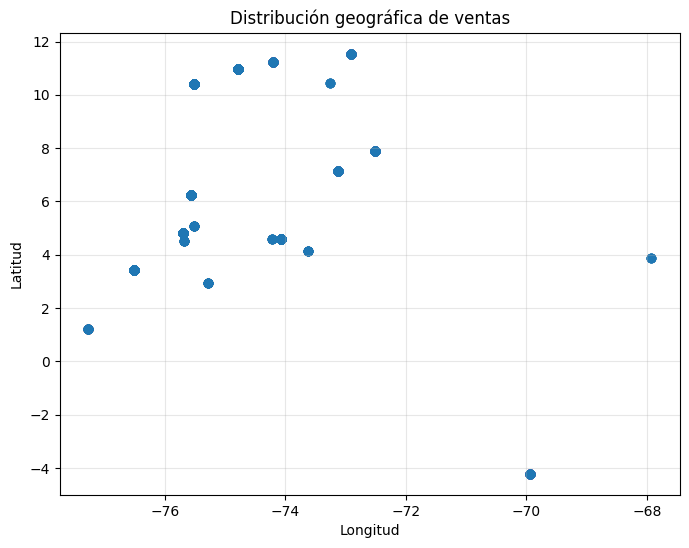

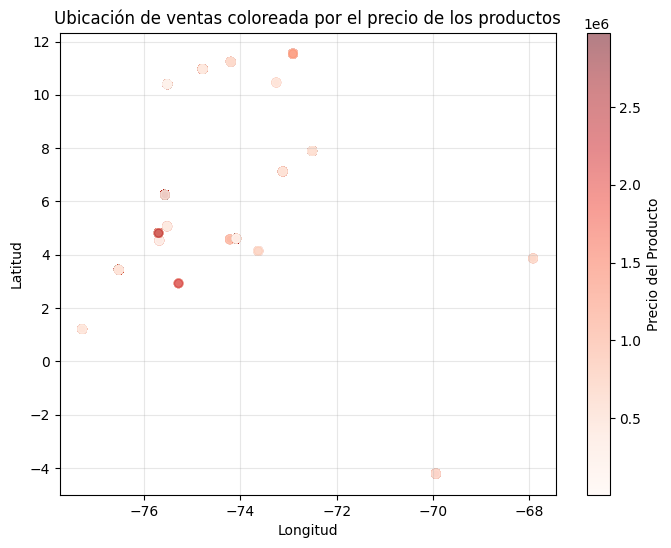

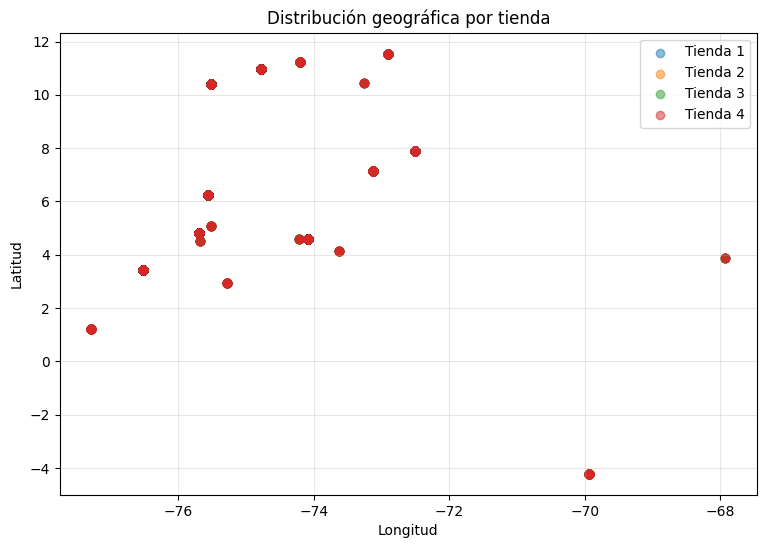

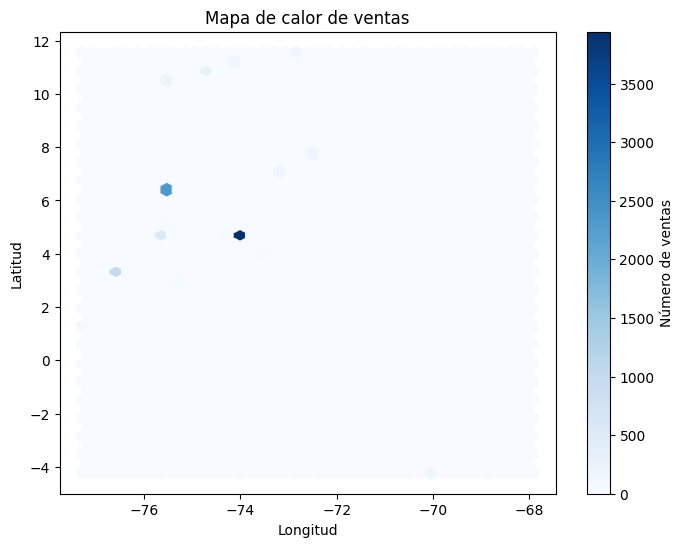

In [290]:
import pandas as pd
import matplotlib.pyplot as plt

# Todas las tiendas en un solo DF
dfs = [tienda1, tienda2, tienda3, tienda4]
nombres = ["Tienda 1", "Tienda 2", "Tienda 3", "Tienda 4"]

# DF sin columna "Tienda"
df = pd.concat(dfs, ignore_index=True)

# DF con columna "Tienda"
df_con_tienda = pd.concat(
    [df_i.assign(Tienda=nombre) for df_i, nombre in zip(dfs, nombres)],
    ignore_index=True
)

# Scatter general
plt.figure(figsize=(8, 6))
plt.scatter(df['lon'], df['lat'], alpha=0.4)
plt.title('Distribución geográfica de ventas')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.grid(alpha=0.3)
plt.show()
plt.close()

# Scatter precio
plt.figure(figsize=(8, 6))
plt.scatter(df['lon'], df['lat'], c=df['Precio'], alpha=0.5, cmap='Reds')
plt.title('Ubicación de ventas coloreada por el precio de los productos')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.colorbar(label='Precio del Producto')
plt.grid(alpha=0.3)
plt.show()
plt.close()

# Scatter tienda
plt.figure(figsize=(9, 6))

for tienda_nombre in df_con_tienda['Tienda'].unique():
    subset = df_con_tienda[df_con_tienda['Tienda'] == tienda_nombre]
    plt.scatter(subset['lon'], subset['lat'], alpha=0.5, label=tienda_nombre)

plt.title('Distribución geográfica por tienda')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.legend()
plt.grid(alpha=0.3)
plt.show()
plt.close()

# Heatmap con hexbin
plt.figure(figsize=(8, 6))
plt.hexbin(df['lon'], df['lat'], gridsize=40, cmap='Blues')
plt.title('Mapa de calor de ventas')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.colorbar(label='Número de ventas')
plt.show()
plt.close()